# Data Exploration: LIAR Binary Credibility MVP

This notebook downloads the LIAR dataset, converts the six-class labels into a binary credibility target, and produces exploratory analysis artifacts for the MVP.

Important scope note: this work predicts credibility of short LIAR-style claims, not full articles and not real-time factual truth.

In [81]:
import os
from pathlib import Path
import re
import string
import zipfile

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

LIAR_ZIP_URL = "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"
PROJECT_ROOT = Path(".").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for path in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, REPORTS_FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 200)


## Download and Extract LIAR

In [82]:
zip_path = RAW_DIR / "liar_dataset.zip"

if not zip_path.exists():
    response = requests.get(LIAR_ZIP_URL, timeout=60)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(INTERIM_DIR)

extracted_files = sorted([p.name for p in INTERIM_DIR.glob("*.tsv")])
print(f"Extracted {len(extracted_files)} files: {extracted_files}")

Extracted 3 files: ['test.tsv', 'train.tsv', 'valid.tsv']


## Load Split Files with Explicit Schema

In [83]:
columns = [
    "statement_id",
    "original_label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context",
]

train_df = pd.read_csv(INTERIM_DIR / "train.tsv", sep="\t", header=None, names=columns)
valid_df = pd.read_csv(INTERIM_DIR / "valid.tsv", sep="\t", header=None, names=columns)
test_df = pd.read_csv(INTERIM_DIR / "test.tsv", sep="\t", header=None, names=columns)

train_df["split"] = "train"
valid_df["split"] = "valid"
test_df["split"] = "test"

df = pd.concat([train_df, valid_df, test_df], ignore_index=True)
print(f"Sanity check! Imported data size (rows, columns): {df.shape}")

Sanity check! Imported data size (rows, columns): (12791, 15)


## Binary Mapping

The ambiguous `half-true` label is dropped in the main experiment to create a cleaner binary task:

- `0 = not_credible` (`pants-fire`, `false`, `barely-true`)
- `1 = credible` (`mostly-true`, `true`)

In [84]:
label_map = {
    "pants-fire": 0,
    "false": 0,
    "barely-true": 0,
    "mostly-true": 1,
    "true": 1,
}

name_map = {
    0: "not_credible",
    1: "credible",
}

df_binary = df[df["original_label"].isin(label_map)].copy()
df_binary["label"] = df_binary["original_label"].map(label_map)
df_binary["label_name"] = df_binary["label"].map(name_map)

print(f"Sanity check! Data size after removing irrelevant labels (rows, columns): {df_binary.shape}")

Sanity check! Data size after removing irrelevant labels (rows, columns): (10164, 17)


In [85]:
stop_words = set(stopwords.words('english'))

In [86]:
def clean_text(text):
    '''Make text lowercase, remove punctuation and remove words containing numbers.'''
    text = text.lower()
    text = re.sub('.*?¿', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('[0-9]+', '', text)
    text = re.sub(r" +", " ", text)
    return text

def remove_stop_words(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(token for token in tokens)

def remove_spaces(text):
    text = re.sub(r" +", " ", text)
    return text

In [87]:
df_binary['statement'] = df_binary['statement'].apply(clean_text)
df_binary['statement'] = df_binary['statement'].apply(remove_stop_words)
df_binary['statement'] = df_binary['statement'].apply(remove_spaces)

In [88]:
df_binary["text_length_chars"] = df_binary["statement"].fillna("").str.len()
df_binary["text_length_words"] = df_binary["statement"].fillna("").str.split().str.len()

In [89]:
df_binary = df_binary[df_binary["text_length_words"].gt(5)].copy()

In [90]:
processed_columns = [
    "split",
    "statement_id",
    "original_label",
    "label",
    "label_name",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state_info",
    "party_affiliation",
    "context",
    "text_length_chars",
    "text_length_words",
]

df_binary = df_binary[processed_columns]

assert set(df_binary["split"].unique()) == {"train", "valid", "test"}
assert set(df_binary["label"].unique()) == {0, 1}
assert "half-true" not in set(df_binary["original_label"].unique())
assert df_binary["statement"].notna().all()

print("Sanity check! All data was split and has correct labels. All rows contain some not empty statement")

Sanity check! All data was split and has correct labels. All rows contain some not empty statement


In [91]:
processed_path = PROCESSED_DIR / "liar_binary.csv"
df_binary.to_csv(processed_path, index=False)

print(f"Sanity check! Processed data file was succesfully saved: {os.path.exists(processed_path)}")

Sanity check! Processed data file was succesfully saved: True


## Row Counts Before and After Binary Filtering

In [92]:
row_count_summary = pd.DataFrame({
    "stage": ["original_liar", "binary_without_half_true"],
    "rows": [len(df), len(df_binary)],
})
print(row_count_summary.to_string(index=False))

                   stage  rows
           original_liar 12791
binary_without_half_true  9210


The binary conversion removes `half-true` statements to reduce class ambiguity in the MVP baseline.

## Class Distribution

In [93]:
class_counts = (
    df_binary["label_name"]
    .value_counts()
    .rename_axis("label_name")
    .reset_index(name="rows")
)
print(class_counts.to_string(index=False))

  label_name  rows
not_credible  5080
    credible  4130


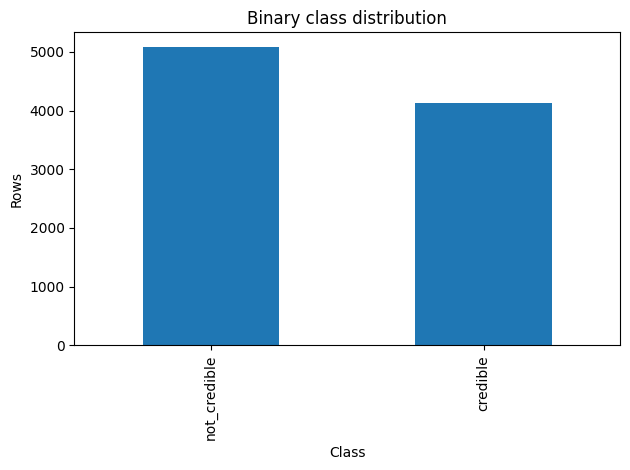

In [94]:
ax = class_counts.plot(kind="bar", x="label_name", y="rows", legend=False)
ax.set_title("Binary class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()

## Split Distribution

In [95]:
split_counts = (
    df_binary["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="rows")
)

print(split_counts.to_string(index=False))

split  rows
train  7348
valid   948
 test   914


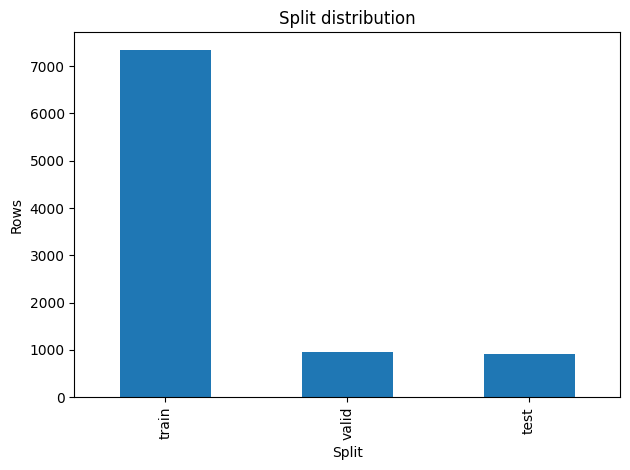

In [96]:
ax = split_counts.plot(kind="bar", x="split", y="rows", legend=False)
ax.set_title("Split distribution")
ax.set_xlabel("Split")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "split_distribution.png", dpi=150)
plt.show()

## Text Length by Class

In [97]:
df_binary.groupby("label_name")[["text_length_chars", "text_length_words"]].agg(["mean", "median", "min", "max"])

text_length_chars                  text_length_words             \
                          mean median min   max              mean median min   
label_name                                                                     
credible             78.946973   72.0  29  2380         11.010169   10.0   6   
not_credible         79.508268   74.0  29  1560         11.094685   10.0   6   

                   
              max  
label_name         
credible      264  
not_credible  177

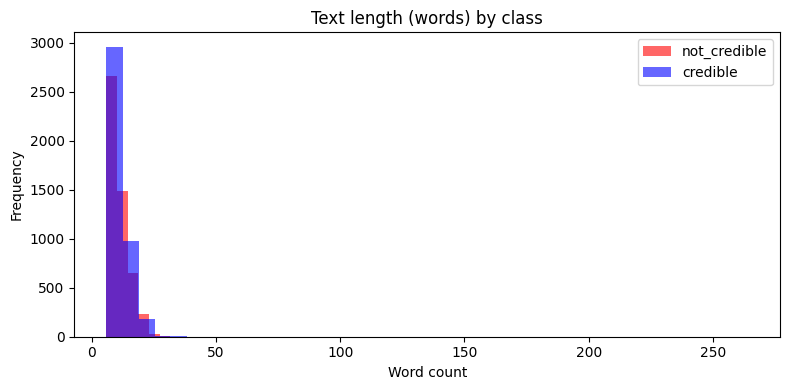

In [98]:
fig, ax = plt.subplots(figsize=(8, 4))
for label_name, color in [("not_credible", "red"), ("credible", "blue")]:
    subset = df_binary[df_binary["label_name"] == label_name]["text_length_words"]
    ax.hist(subset, bins=40, alpha=0.6, label=label_name, color=color)
ax.set_title("Text length (words) by class")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "text_length_by_class.png", dpi=150)
plt.show()

## Exclude super short statements

## Top Subject Categories

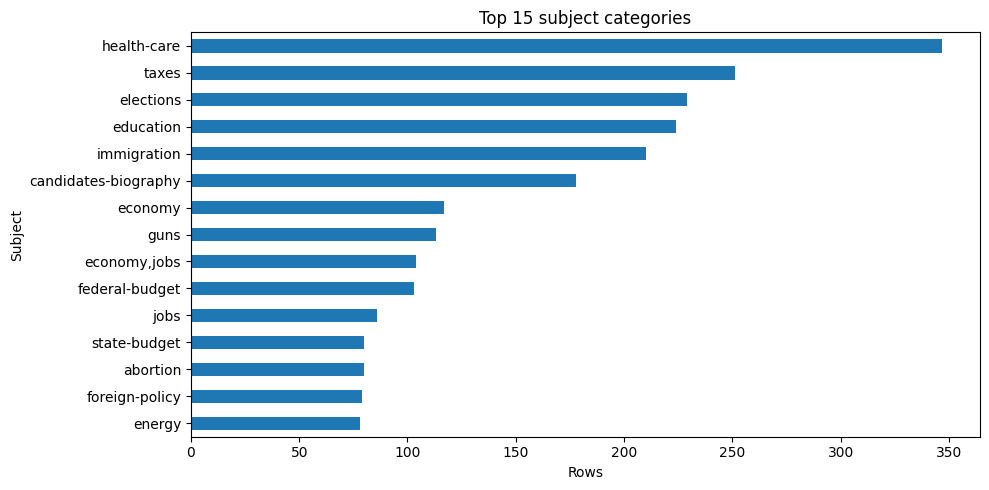

In [99]:
top_subjects = df_binary["subject"].fillna("missing").value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_subjects.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 subject categories")
ax.set_xlabel("Rows")
ax.set_ylabel("Subject")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "top_subjects.png", dpi=150)
plt.show()

## Missing Value Summary

In [100]:
missing_summary = (
    df_binary.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
print(missing_summary.to_string(index=False))

           column  missing_count
      speaker_job           2624
       state_info           2056
          context             86
          subject              2
          speaker              2
party_affiliation              2
            split              0
     statement_id              0
   original_label              0
            label              0
       label_name              0
        statement              0
text_length_chars              0
text_length_words              0


Missingness exists mostly in metadata fields (for example `speaker_job`, `state_info`, `party_affiliation`). The core text-only modeling path relies on `statement`, so this does not block the main baselines.

## Example Statements From Both Classes

In [101]:
for label_name in ["not_credible", "credible"]:
    print(f"\nExamples for {label_name}:")
    display(
        df_binary[df_binary["label_name"] == label_name][
            ["original_label", "label_name", "statement", "subject", "speaker"]
        ].sample(5, random_state=42)
    )


Examples for not_credible:


,original_label,label_name,statement,subject,speaker
5902,false,not_credible,crime decline united states would fairly small wasnt crime decline new york city,crime,rudy-giuliani
9594,false,not_credible,know obamacare cost nearly twice much initially expected trillion,health-care,ted-cruz
82,false,not_credible,past years egypt made great strides political democratic reform,"foreign-policy,abc-news-week",sameh-shoukry
3110,barely-true,not_credible,ronald reagan came economic growth averaged less percent year theres one fouryear period thats true thats true,"economy,history,jobs",ted-cruz
7808,barely-true,not_credible,year austin city council granted small homestead property tax exemption applied equally everyone also granted exemption elderly disabled members community,taxes,sheryl-cole



Examples for credible:


,original_label,label_name,statement,subject,speaker
5662,true,credible,medicare spends billion year subsidies insurance companies,health-care,barack-obama
3685,mostly-true,credible,richest percent financial wealth bottom percent combined,"economy,poverty,workers",michael-moore
5839,mostly-true,credible,florida doesnt regulate assault weapons caliber rifles largecapacity ammunition magazines doesnt require permit purchase gun doesnt require registration whatsoever,guns,hillary-clinton
5352,mostly-true,credible,koch industries among worst toxic air pollution entire united states churns climatechanging greenhouse gases oil giants chevron shell valero,environment,harry-reid
3254,mostly-true,credible,nationwide tuition public universities almost percent last years,education,joe-biden
